# Mathematical Tools


## Approximation

In [5]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

In [6]:
plt.style.use('seaborn-v0_8')
mpl.rcParams['font.family'] = 'serif'
%matplotlib inline

Throughout this section, the main example function is the following, which is com‐
prised of a trigonometric term and a linear term:

In [7]:
def f(x):
    return np.sin(x)+0.5*x 

Approximation of this function over a given interval by regres‐
sion and interpolation techniques. First, a plot of the function to get a better view of
what exactly the approximation shall achieve. The interval of interest shall be [–2π,
2π]. Figure 11-1 displays the function over the fixed interval defined via the np.lin
space() function. The function create_plot() is a helper function to create the
same type of plot required multiple times in this chapter

In [8]:
def create_plot(x,y,styles,labels,axlabels):
    plt.figure(figsize=(10,6))
    for i in range(len(x)):
        plt.plot(x[i],y[i],styles[i],label=labels[i])
        plt.xlabel(axlabels[0])
        plt.ylabel(axlabels[1])
    plt.legend()
    

In [9]:
x = np.linspace(-2*np.pi,2*np.pi,50)


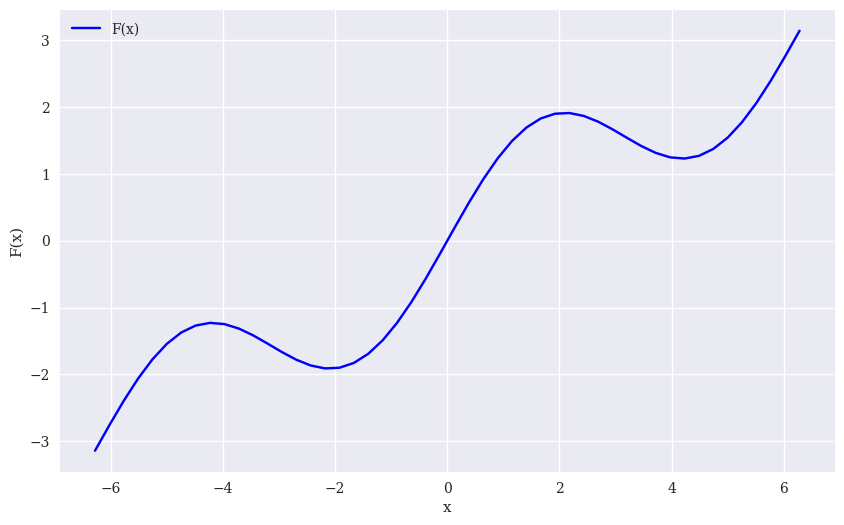

In [10]:
create_plot([x],[f(x)],['b'],['F(x)'],['x','F(x)'])

### Regression

Regression is a rather efficient tool when it comes to function approximation. It is
not only suited to approximating one-dimensional functions but also works well in
higher dimensions. The numerical techniques needed to come up with regression
results are easily implemented and quickly executed. Basically, the task of regression,
given a set of so-called basis functions bd
, d ∈ {1, . ⋯ , D}, is to find optimal param‐
eters α1
*
, ⋯ , αD
*
 according to Minimization problem of Regression, where yi ≡ f (xi) for i ∈ {1, ⋯ , I}
observation points. The xi
 are considered independent observations and the yi depen‐
dent observations (in a functional or statistical sense).

#### Monomials as basis functions

One of the simplest cases is to take monomials as basis functions—i.e.,
b1 = 1, b2 = x, b3 = x
2
, b4 = x
3
, ⋯ . In such a case, NumPy has built-in functions for
both the determination of the optimal parameters (namely, np.polyfit()) and the
evaluation of the approximation given a set of input values (namely, np.polyval())

In [11]:
# Linear Regression Step
res = np.polyfit(x,f(x),deg=1,full=True)
# x : x cordinate ( independent variable values)
# y : y cordinate (dependent variable values)
# deg : Degree of the fittig polynomial 
# full : if True , returns diagnostic information in addition
# w : wights to apply to the y cordinates 
# cov : if True, returns covariance matrix in addition

Given the returned
optimal regression coefficients p from np.polyfit(), np.polyval(p, x) then
returns the regression values for the x coordinates

In [12]:
# Full results , regressio parameters ,
#  residuals , effective ranks , singular values , and relative conditional number 
res

(array([ 4.28841952e-01, -5.49532361e-17]),
 array([21.03238686]),
 np.int32(2),
 array([1., 1.]),
 np.float64(1.1102230246251565e-14))

In [13]:
ry = np.polyval(res[0],x)

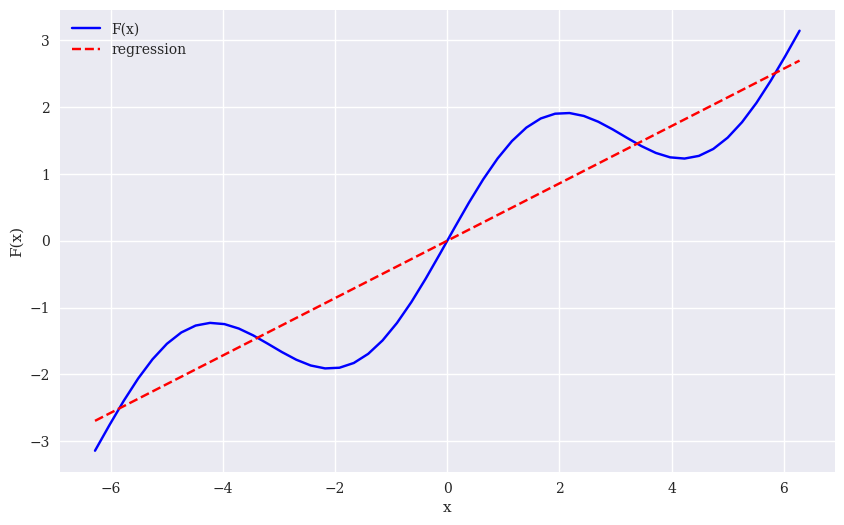

In [14]:
create_plot([x,x],[f(x),ry],['b','r--'],['F(x)','regression'],['x','F(x)'])

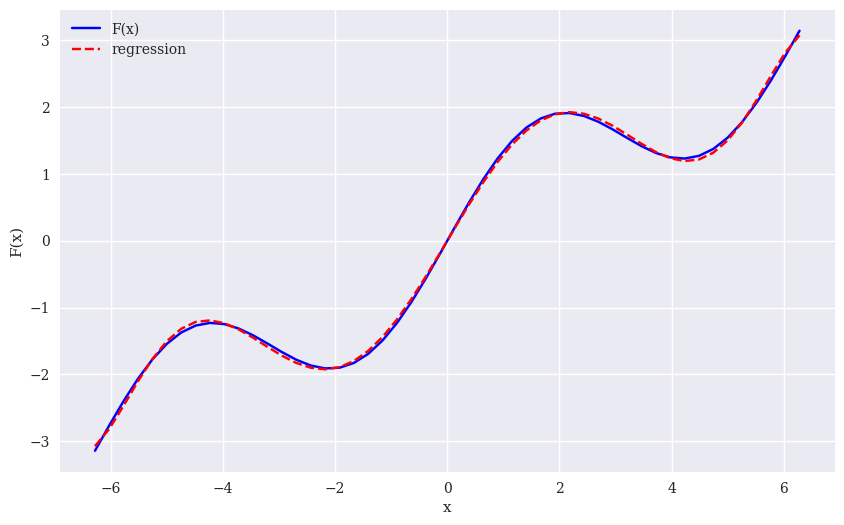

In [15]:
res = np.polyfit(x,f(x),deg=7,full=True)
ry = np.polyval(res[0],x)
create_plot([x,x],[f(x),ry],['b','r--'],['F(x)','regression'],['x','F(x)'])

Checks whether the function and regression values are the same (or at least
close)

In [16]:
np.allclose(f(x),ry)


False

Calculates the Mean Squared Error (MSE) for the regression values given the
function values

In [17]:
np.mean((f(x)-ry)**2)

np.float64(0.00177691347595176)

### Individual basis function


In general, one can reach better regression results by choosing better sets of basis
functions, e.g., by exploiting knowledge about the function to approximate. In this
case, the individual basis functions have to be defined via a matrix approach (i.e.,
using a NumPy ndarray object). First, the case with monomials up to order 3
(Figure 11-5). The central function here is np.linalg.lstsq()

The basis function values from constant to cubic

In [18]:
matrix = np.zeros((3+1,len(x)))
matrix[3,:] = x ** 3
matrix[2,:] = x ** 2
matrix[1,:] = x 
matrix[0,:] = 1
matrix

array([[ 1.00000000e+00,  1.00000000e+00,  1.00000000e+00,
         1.00000000e+00,  1.00000000e+00,  1.00000000e+00,
         1.00000000e+00,  1.00000000e+00,  1.00000000e+00,
         1.00000000e+00,  1.00000000e+00,  1.00000000e+00,
         1.00000000e+00,  1.00000000e+00,  1.00000000e+00,
         1.00000000e+00,  1.00000000e+00,  1.00000000e+00,
         1.00000000e+00,  1.00000000e+00,  1.00000000e+00,
         1.00000000e+00,  1.00000000e+00,  1.00000000e+00,
         1.00000000e+00,  1.00000000e+00,  1.00000000e+00,
         1.00000000e+00,  1.00000000e+00,  1.00000000e+00,
         1.00000000e+00,  1.00000000e+00,  1.00000000e+00,
         1.00000000e+00,  1.00000000e+00,  1.00000000e+00,
         1.00000000e+00,  1.00000000e+00,  1.00000000e+00,
         1.00000000e+00,  1.00000000e+00,  1.00000000e+00,
         1.00000000e+00,  1.00000000e+00,  1.00000000e+00,
         1.00000000e+00,  1.00000000e+00,  1.00000000e+00,
         1.00000000e+00,  1.00000000e+00],
       [-6.28

Regression Step 

In [19]:
reg = np.linalg.lstsq(matrix.T,f(x),rcond=None)[0]
reg

array([ 1.16778801e-14,  5.62777448e-01, -8.88178420e-16, -5.43553615e-03])

The optimal regression parameters

In [20]:
reg.round(4)

array([ 0.    ,  0.5628, -0.    , -0.0054])

Regression estimates for the function values

In [21]:
ry = np.dot(reg,matrix)

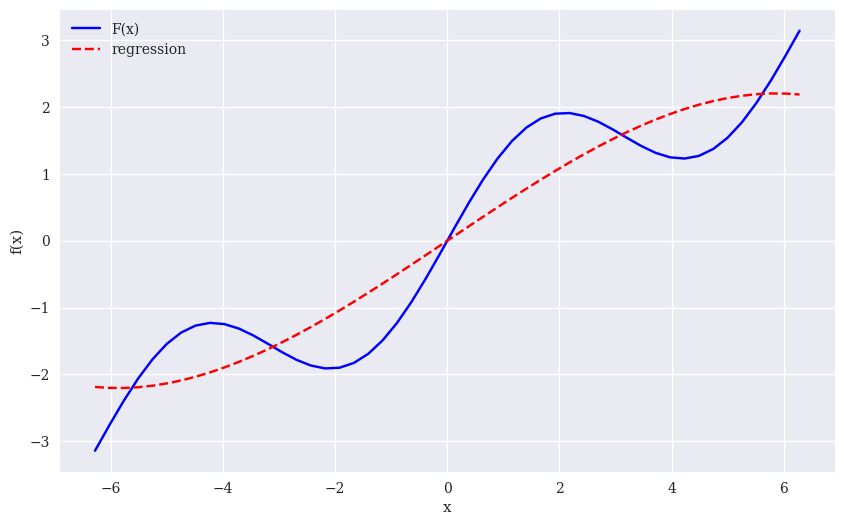

In [22]:
create_plot([x,x],[f(x),ry],['b','r--'],['F(x)','regression'],['x','f(x)'])

The result in Figure above is not as good as expected based on our previous experience.
with monomials. Using the more general approach allows us to exploit knowledge
about the example function—namely that there is a sin part in the function. Therefore, it makes sense to include a sine function in the set of basis functions. For simplicity, the highest-order monomial is replaced. The fit now is perfect, as the numbers

In [23]:
matrix[3,:] = np.sin(x)

In [24]:
reg = np.linalg.lstsq(matrix.T,f(x),rcond=None)[0]

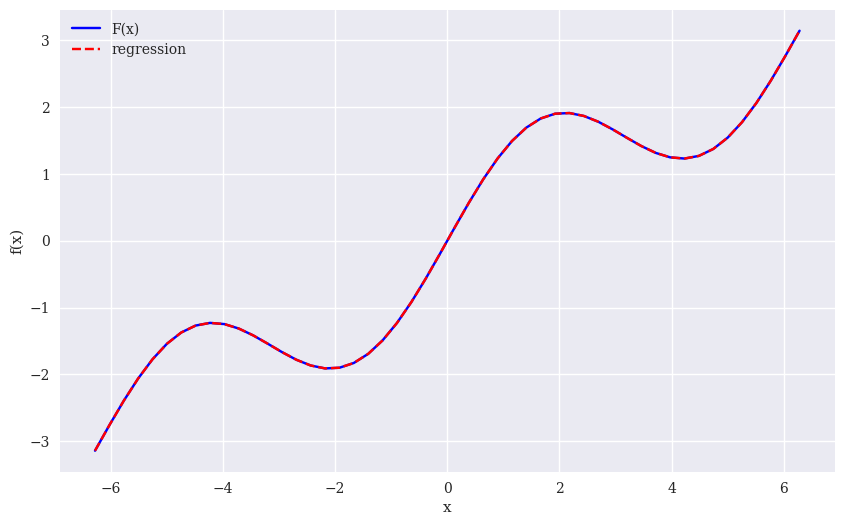

In [25]:
ry = np.dot(reg,matrix)
create_plot([x,x],[f(x),ry],['b','r--'],['F(x)','regression'],['x','f(x)'])

In [26]:
np.allclose(f(x),ry)

True

### Noisy data

Regression can cope equally well with noisy data, be it data from simulation or from
(nonperfect) measurements. To illustrate this point, independent observations with
noise and dependent observations with noise are generated. Figure below reveals that
the regression results are closer to the original function than the noisy data points. In
a sense, the regression averages out the noise to some extent

In [27]:
xn = np.linspace(-2*np.pi,2*np.pi,50)
xn = xn + 0.15 * np.random.standard_normal(len(xn))
yn = f(xn) + 0.25* np.random.standard_normal(len(xn))

In [28]:
reg = np.polyfit(xn,yn,7)
ry = np.polyval(reg,xn)

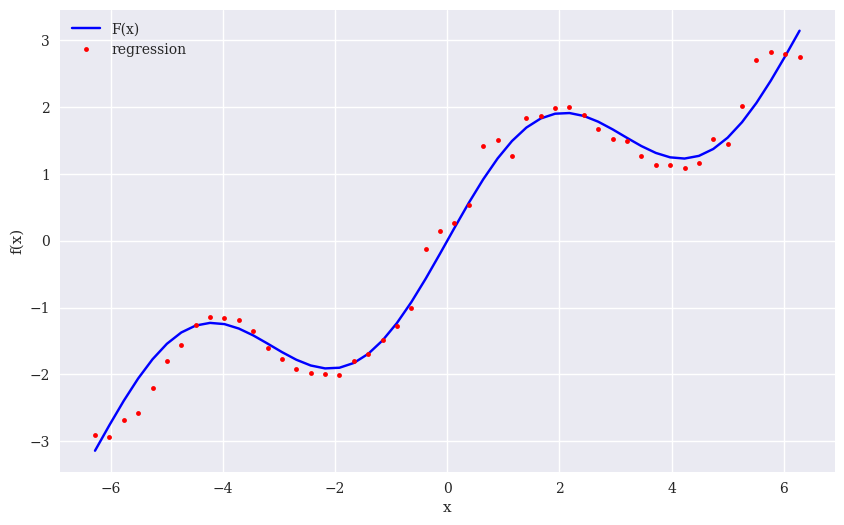

In [29]:
create_plot([x,x],[f(x),ry],['b','r.'],['F(x)','regression'],['x','f(x)'])

### Unsorted data 

Another important aspect of regression is that the approach also works seamlessly
with unsorted data. The previous examples all rely on sorted x data. This does not
have to be the case. To make the point, let’s look at yet another randomization
approach for the x values. In this case, one can hardly identify any structure by just
visually inspecting the raw data

In [30]:
xu = np.random.rand(50) * 4 * np.pi  - 2* np.pi
yu = f(xu)


In [31]:
print(xu[:].round(2))
print(yu[:].round(2))

[ 2.02 -5.68 -1.72 -1.55 -0.66  2.35  1.23  0.24  0.67  4.19  4.86  4.5
 -4.91  4.94 -2.07 -5.32 -5.45 -4.45 -2.83  2.95  5.96 -0.82  2.2  -5.85
 -2.    1.78  1.52  2.83 -2.45  2.43 -5.74 -3.74 -0.04 -4.35 -2.23  6.13
  0.69 -1.34 -4.58  0.72 -3.5   3.56 -5.86 -1.4   1.31  3.18 -4.94 -1.73
 -2.04 -0.1 ]
[ 1.91 -2.27 -1.85 -1.77 -0.95  1.89  1.56  0.36  0.96  1.23  1.44  1.27
 -1.47  1.5  -1.91 -1.84 -1.98 -1.26 -1.72  1.67  2.66 -1.14  1.91 -2.51
 -1.91  1.87  1.76  1.72 -1.86  1.87 -2.35 -1.31 -0.06 -1.24 -1.9   2.92
  0.99 -1.64 -1.3   1.02 -1.4   1.37 -2.52 -1.68  1.62  1.55 -1.5  -1.85
 -1.91 -0.15]


In [32]:
reg = np.polyfit(xu,yu,5) # remeber its polyfit 
ry = np.polyval(reg,xu)

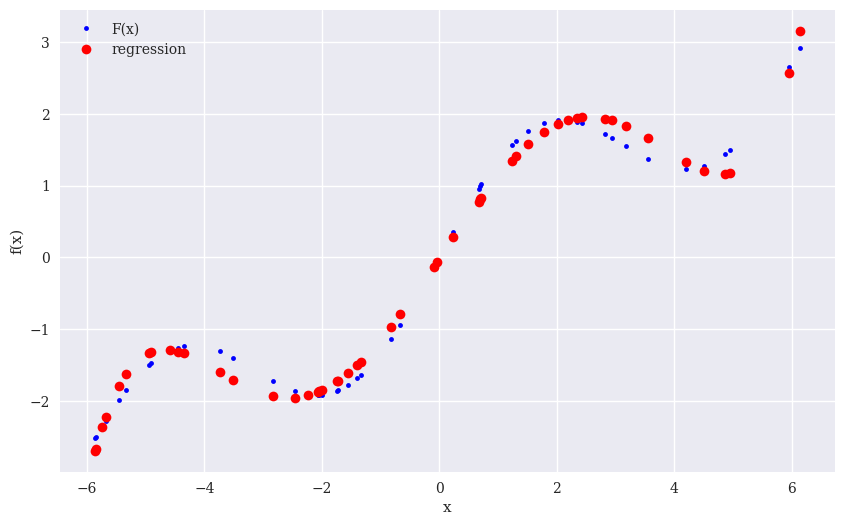

In [33]:
create_plot([xu,xu],[yu,ry],['b.','ro'],['F(x)','regression'],['x','f(x)'])

### Multiple Dimension

Another convenient characteristic of the least-squares regression approach is that it
carries over to multiple dimensions without too many modifications. As an example
function take fm(), as presented next:

In [34]:
def fm(p):
    x,y = p
    return np.sin(x) + 0.25 * x + np.sqrt(y) + 0.05 * y ** 2


In [35]:
x = np.linspace(0,10,20)
y = np.linspace(0,10,20)
X,Y = np.meshgrid(x,y) # generates the 2D ndarray objects ('Grids")

Z = fm((X,Y))
x = X.flatten() # yields 1 d array objects from the 2D ndarray objects
y = Y.flatten()

In [36]:
from mpl_toolkits.mplot3d import Axes3D

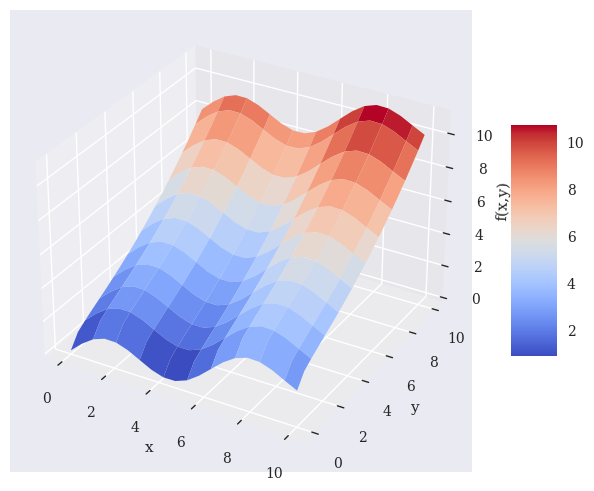

In [37]:
fig = plt.figure(figsize=(10,6))
ax = fig.add_subplot(111,projection='3d')
surf = ax.plot_surface(X,Y,Z, 
               rstride = 2 ,cstride =2,
               cmap = 'coolwarm', linewidth = 0.5,
               antialiased = True)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('f(x,y)')
fig.colorbar(surf,shrink=0.5,aspect =5)

In [38]:
matrix = np.zeros((len(x),6+1))
matrix[:,6] = np.sqrt(y)
matrix[:,5] = np.sin(x)
matrix[:,4] = y**2
matrix[:,3] = x**2
matrix[:,2] = y
matrix[:,1] = x
matrix[:,0] = 1

C:\Users\vipul\AppData\Local\Temp\ipykernel_50032\1701442301.py:20: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


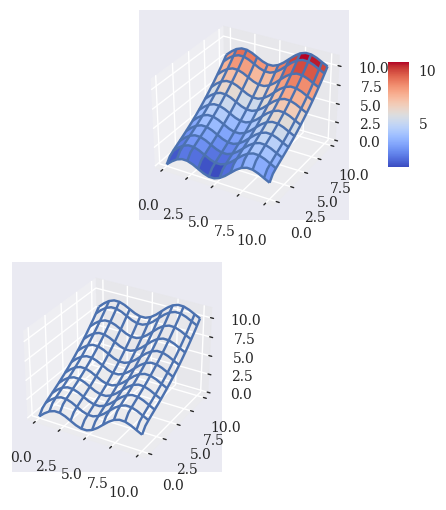

In [39]:
reg = np.linalg.lstsq(matrix,fm((x,y)),rcond=None)[0]
#Transforms the regression results to the grid structure
RZ = np.dot(matrix,reg).reshape((20,20))

fig = plt.figure(figsize=(10,6))

ax1 = fig.add_subplot(211,projection='3d')
ax2 = fig.add_subplot(212,projection='3d')
surf1 = ax1.plot_surface(X, Y, Z, rstride=2, cstride=2,
 cmap=mpl.cm.coolwarm, linewidth=0.5,
 antialiased=True)
surf2 = ax1.plot_wireframe(X, Y, RZ, rstride=2, cstride=2,
 label='regression') 
surf2 = ax2.plot_wireframe(X, Y, RZ, rstride=2, cstride=2,
 label='regression')

ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('f(x, y)')
ax.legend()
fig.colorbar(surf1, shrink=0.5, aspect=5)


In [40]:
np.allclose(RZ,fm((X,Y)))

True

### Interpolation

Compared to regression, interpolation (e.g., with cubic splines) is more involved
mathematically. It is also limited to low-dimensional problems. Given an ordered set
of observation points (ordered in the x dimension), the basic idea is to do a regres‐
sion between two neighboring data points in such a way that not only are the data
points perfectly matched by the resulting piecewise-defined interpolation function,
but also the function is continuously differentiable at the data points. Continuous dif‐
ferentiability requires at least interpolation of degree 3—i.e., with cubic splines. How‐
ever, the approach also works in general with quadratic and even linear splines.

In [41]:
import scipy.interpolate as spi

True

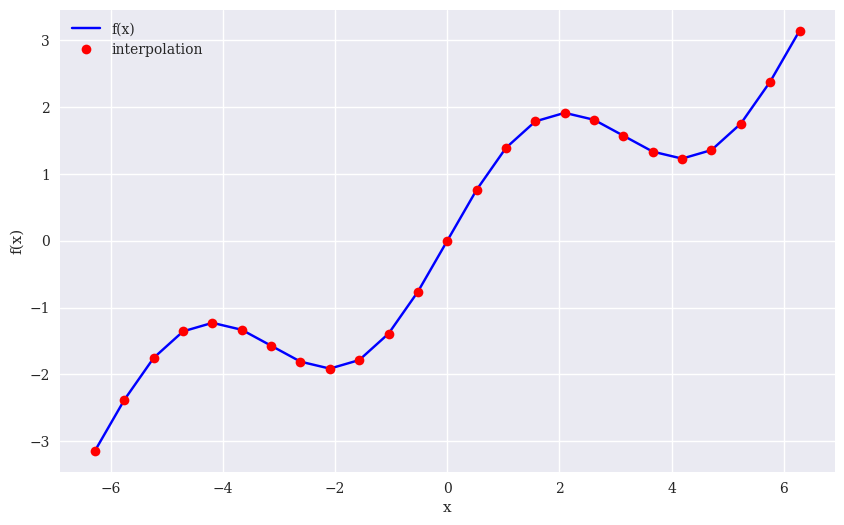

In [42]:
x = np.linspace(-2*np.pi,2*np.pi,25)
def f(x):
    return np.sin(x) + 0.5 *x
 # Implements the linear spline interpolation 
ipo = spi.splrep(x,f(x),k=1)
# Derive the interpolated values
iy = spi.splev(x,ipo)

create_plot([x, x], [f(x), iy], ['b', 'ro'],
 ['f(x)', 'interpolation'], ['x', 'f(x)'])

np.allclose(f(x),iy)

In [43]:
np.mean((f(x)-iy)**2)

np.float64(0.0)

The application itself, given an x-ordered set of data points, is as simple as the appli‐
cation of np.polyfit() and np.polyval(). Here, the respective functions are sci.splrep() and sci.splev().

![paramters that this functions takes as input](new.png)

Spline interpolation is often used in finance to generate estimates for dependent val‐
ues of independent data points not included in the original observations. To this end,
the next example picks a much smaller interval and has a closer look at the interpola‐
ted values with the linear splines.

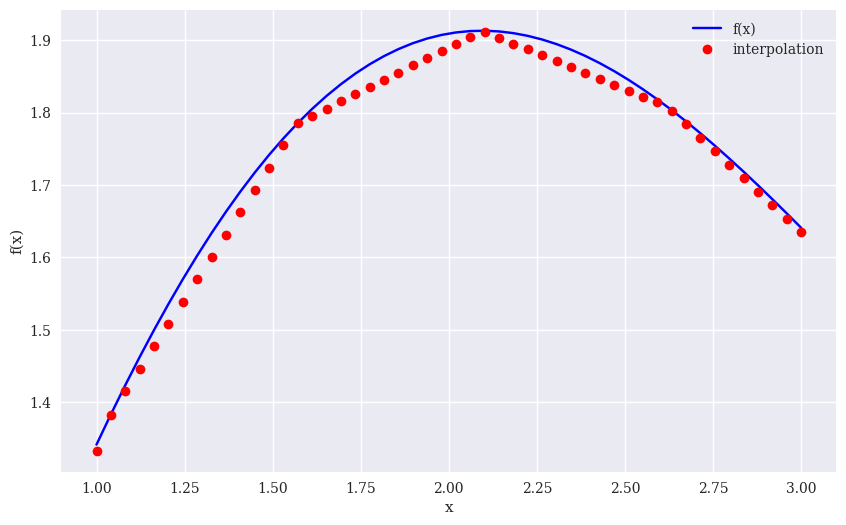

In [44]:
xd = np.linspace(1.0,3.0,50)
iyd = spi.splev(xd,ipo)

create_plot([xd,xd],[f(xd),iyd],['b','ro'],['f(x)', 'interpolation'], ['x', 'f(x)'])

it is evident that the function is not
continuously differentiable at the original data points—another drawback:

A repetition of the complete exercise, this time using cubic splines, improves the
results considerably

In [45]:
ipo = spi.splrep(x,f(x),k=3)
iyd = spi.splev(xd,ipo)

In [46]:
np.allclose(f(xd),iyd)

False

In [47]:
np.mean((f(xd)-iyd)**2)

np.float64(1.1349319851436252e-08)

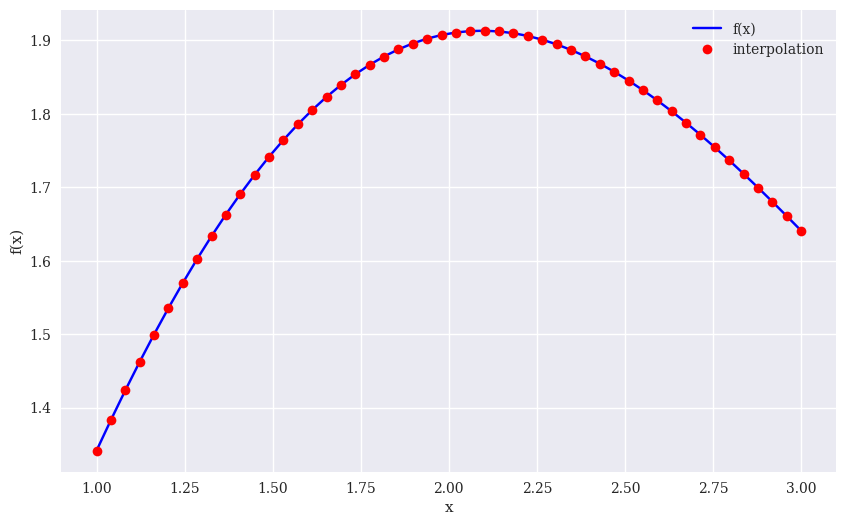

In [48]:

create_plot([xd,xd],[f(xd),iyd],['b','ro'],['f(x)', 'interpolation'], ['x', 'f(x)'])

#### Last Note 

In those cases where spline interpolation can be applied, one can
expect better approximation results compared to a least-squares
regression approach. However, remember that sorted (and “nonnoisy”) data is required and that the approach is limited to lowdimensional problems. It is also computationally more demanding
and might therefore take (much) longer than regression in certain
use cases.


## Convex Optimisation

In finance and economics, convex optimization plays an important role. Examples are
the calibration of option pricing models to market data or the optimization of an
agent’s utility function. As an example, take the function fm()

In [49]:
def fm(p):
    x,y = p
    return (np.sin(x)+0.05*x ** 2+ np.sin(y)+ 0.05*y**2)


x= np.linspace(-10,10,50)
y = np.linspace(-10,10,50)

X,Y = np.meshgrid(x,y)

Z = fm((X,Y))


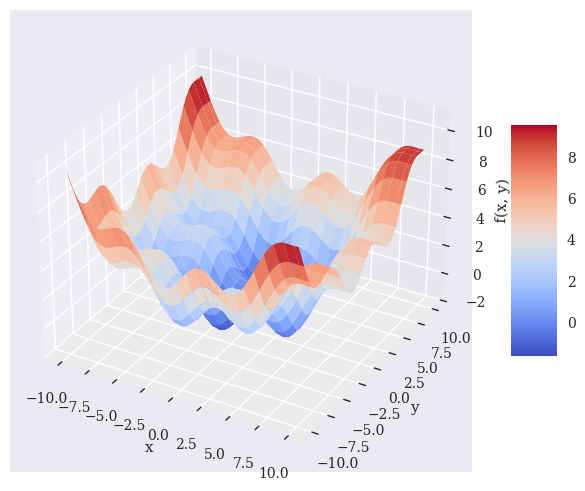

In [50]:
fig = plt.figure(figsize=(10,6))

ax = fig.add_subplot(111,projection='3d')
surf = ax.plot_surface( X,Y,Z, rstride=2, cstride=2,
 cmap='coolwarm', linewidth=0.5,
 antialiased=True)

ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('f(x, y)')
fig.colorbar(surf, shrink=0.5, aspect=5)


#### Global Optimization

In [51]:
import scipy.optimize as sco

In [54]:
def fo(p):
    x,y = p
    z = np.sin(x)+ 0.05 * x ** 2 + np.sin(y) + 0.05 * y ** 2
    if output == True:
        print('%8.4f | %8.4f | %8.4f' %(x,y,z))
    return z


In [56]:
output = True
sco.brute(fo,((-10,10.1,5),(-10,10.1,5)),finish=None)

-10.0000 | -10.0000 |  11.0880
-10.0000 |  -5.0000 |   7.7529
-10.0000 |   0.0000 |   5.5440
-10.0000 |   5.0000 |   5.8351
-10.0000 |  10.0000 |  10.0000
 -5.0000 | -10.0000 |   7.7529
 -5.0000 |  -5.0000 |   4.4178
 -5.0000 |   0.0000 |   2.2089
 -5.0000 |   5.0000 |   2.5000
 -5.0000 |  10.0000 |   6.6649
  0.0000 | -10.0000 |   5.5440
  0.0000 |  -5.0000 |   2.2089
  0.0000 |   0.0000 |   0.0000
  0.0000 |   5.0000 |   0.2911
  0.0000 |  10.0000 |   4.4560
  5.0000 | -10.0000 |   5.8351
  5.0000 |  -5.0000 |   2.5000
  5.0000 |   0.0000 |   0.2911
  5.0000 |   5.0000 |   0.5822
  5.0000 |  10.0000 |   4.7471
 10.0000 | -10.0000 |  10.0000
 10.0000 |  -5.0000 |   6.6649
 10.0000 |   0.0000 |   4.4560
 10.0000 |   5.0000 |   4.7471
 10.0000 |  10.0000 |   8.9120


array([0., 0.])

In [63]:
opt1 = sco.brute(fo,((-10,10.1,0.1),(-10,10.1,0.1)),finish=None)
opt1

-10.0000 | -10.0000 |  11.0880
-10.0000 |  -9.9000 |  10.9021
-10.0000 |  -9.8000 |  10.7125
-10.0000 |  -9.7000 |  10.5203
-10.0000 |  -9.6000 |  10.3263
-10.0000 |  -9.5000 |  10.1317
-10.0000 |  -9.4000 |   9.9372
-10.0000 |  -9.3000 |   9.7441
-10.0000 |  -9.2000 |   9.5531
-10.0000 |  -9.1000 |   9.3654
-10.0000 |  -9.0000 |   9.1819
-10.0000 |  -8.9000 |   9.0035
-10.0000 |  -8.8000 |   8.8311
-10.0000 |  -8.7000 |   8.6656
-10.0000 |  -8.6000 |   8.5076
-10.0000 |  -8.5000 |   8.3580
-10.0000 |  -8.4000 |   8.2174
-10.0000 |  -8.3000 |   8.0863
-10.0000 |  -8.2000 |   7.9653
-10.0000 |  -8.1000 |   7.8546
-10.0000 |  -8.0000 |   7.7547
-10.0000 |  -7.9000 |   7.6656
-10.0000 |  -7.8000 |   7.5875
-10.0000 |  -7.7000 |   7.5204
-10.0000 |  -7.6000 |   7.4641
-10.0000 |  -7.5000 |   7.4185
-10.0000 |  -7.4000 |   7.3833
-10.0000 |  -7.3000 |   7.3581
-10.0000 |  -7.2000 |   7.3424
-10.0000 |  -7.1000 |   7.3356
-10.0000 |  -7.0000 |   7.3370
-10.0000 |  -6.9000 |   7.3461
-10.0000

array([-1.4, -1.4])

In [64]:
fm(opt1)

np.float64(-1.7748994599769203)

#### Local Optimization

In [65]:
output = True
opt2 = sco.fmin(fo,opt1, xtol = 0.001, ftol = 0.001,maxiter=15, maxfun= 20)

 -1.4000 |  -1.4000 |  -1.7749
 -1.4700 |  -1.4000 |  -1.7743
 -1.4000 |  -1.4700 |  -1.7743
 -1.3300 |  -1.4700 |  -1.7696
 -1.4350 |  -1.4175 |  -1.7756
 -1.4350 |  -1.3475 |  -1.7722
 -1.4088 |  -1.4394 |  -1.7755
 -1.4438 |  -1.4569 |  -1.7751
 -1.4328 |  -1.4427 |  -1.7756
 -1.4591 |  -1.4208 |  -1.7752
 -1.4213 |  -1.4347 |  -1.7757
 -1.4235 |  -1.4096 |  -1.7755
 -1.4305 |  -1.4344 |  -1.7757
 -1.4168 |  -1.4516 |  -1.7753
 -1.4305 |  -1.4260 |  -1.7757
 -1.4396 |  -1.4257 |  -1.7756
 -1.4259 |  -1.4325 |  -1.7757
 -1.4259 |  -1.4241 |  -1.7757
 -1.4304 |  -1.4177 |  -1.7757
 -1.4270 |  -1.4288 |  -1.7757


C:\Users\vipul\AppData\Local\Temp\ipykernel_50032\1688088547.py:2: RuntimeWarning: Maximum number of function evaluations has been exceeded.
  opt2 = sco.fmin(fo,opt1, xtol = 0.001, ftol = 0.001,maxiter=15, maxfun= 20)


In [66]:
opt2

array([-1.42702972, -1.42876755])

In [67]:
fm(opt2)

np.float64(-1.7757246992239009)

For many convex optimization problems it is advisable to have a global minimization
before the local one. The major reason for this is that local convex optimization algo‐
rithms can easily be trapped in a local minimum (or do “basin hopping”), ignoring
completely better local minima and/or a global minimum. The following shows that
setting the starting parameterization to x = y = 2 gives, for example, a “minimum”
value of above zer

In [69]:
output = False
opt2 = sco.fmin(fo,(2.0,2.0),maxiter = 250)
opt2

Optimization terminated successfully.
         Current function value: 0.015826
         Iterations: 46
         Function evaluations: 86


array([4.2710728 , 4.27106945])

In [72]:
print(fm(opt2))
print(fm((2.0,2.0)))

0.0158257532746805
2.2185948536513633


#### Constrained Optimization

So far, this section only considers unconstrained optimization problems. However,
large classes of economic or financial optimization problems are constrained by one
or multiple constraints. Such constraints can formally take on the form of equalities
or inequalities.
As a simple example, consider the utility maximization problem of an (expected util‐
ity maximizing) investor who can invest in two risky securities. Both securities cost qa
= qb
 = 10 USD today. After one year, they have a payoff of 15 USD and 5 USD,
respectively, in state u, and of 5 USD and 12 USD, respectively, in state d. Both states
are equally likely. Denote the vector payoffs for the two securities by ra
 and rb
,
respectively.
The investor has a budget of w0
 = 100 USD to invest and derives utility from future
wealth according to the utility function u(w) = w, where w is the wealth (USD
amount) available. Equation 11-2 is a formulation of the maximization problem
where a, b are the numbers of securities bought by the investor

##### Mathematical equation

$min_{
a,b
} 
–E(u(w1)) = – (0.5 · w_{1u} + 0.5 · w_{1d}
) \\ 
w_{1u} = a · 15 + b · 5 + 100 - a*10 - b*10 \\
w_{1d} = a · 5 + b · 12 + 100 - a*10 - b*10 \\
100 ≥ a · 10 + b · 10\\
a, b ≥ 0$

i am also including the uninvested money in the wealth which was not in the case of book

In [73]:
import math

In [74]:
# function to be minimized 
def Eu(p):
    s,b = p 
    return -((0.5*math.sqrt(s*15+b*5+100-10*(s+b)))+0.5*math.sqrt(s * 5 + b * 12+100-10*(s+b)))


In [75]:
# the inequality constraint as a dict object 
cons = ({'type':'ineq',
         'fun': lambda p:100-p[0]*10-p[1]*10})


In [76]:
#The boundary values for the parameters 
bnds = ((0,1000),(0,1000))

In [77]:
#costraint optimization
result = sco.minimize(Eu,[5,5],method='SLSQP',bounds=bnds,constraints=cons)

In [80]:
#The optimal parameter values (i.e., the optimal portfolio
result['x']

array([1.18896733e-05, 0.00000000e+00])

In [82]:
#The negative minimum function value as the optimal solution value
-result['fun']

9.99999999999956

In [83]:
#The budget constraint is binding; Almost no money is invested 
np.dot(result['x'],[10,10])

np.float64(0.00011889673256515812)

if you do not include money remaining in the final wealth you will get the optimal solution is all money is invested 

## Integration 

Especially when it comes to valuation and option pricing, integration is an important
mathematical tool. This stems from the fact that risk-neutral values of derivatives can
be expressed in general as the discounted expectation of their payoff under the riskneutral or martingale measure. The expectation in turn is a sum in the discrete case
and an integral in the continuous case. The subpackage scipy.integrate provides
different functions for numerical integration

In [84]:
import scipy.integrate as sci

In [85]:
def f(x):
    return np.sin(x)+0.5*x

In [87]:
x = np.linspace(0,10)
y=f(x)
a=0.5
b=9.5
Ix = np.linspace(a,b)
Iy = f(Ix)



In [92]:
from matplotlib.patches import Polygon

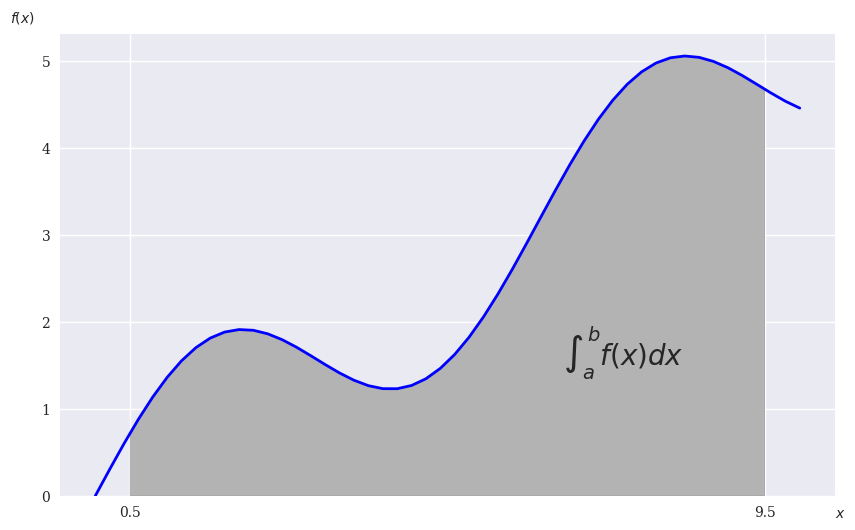

In [98]:
# visualise the integreal value as the gray shaded area under the function
fig,ax = plt.subplots(figsize=(10, 6))
plt.plot(x, y, 'b', linewidth=2)
plt.ylim(bottom=0)
verts = [(a, 0)] + list(zip(Ix, Iy)) + [(b, 0)]
poly = Polygon(verts, facecolor='0.7', edgecolor='0.5')
ax.add_patch(poly)
plt.text(0.75 * (a + b), 1.5, r"$\int_a^b f(x)dx$",
horizontalalignment='center', fontsize=20)
plt.figtext(0.9, 0.075, '$x$')
plt.figtext(0.075, 0.9, '$f(x)$')
ax.set_xticks((a, b))


#### Numerical Integration

fixed_quad: Fixed-Order Gaussian Quadrature

The Intuition

Imagine you want to estimate the area under a curve. A basic approach (like the Trapezoidal rule) evaluates the function at evenly spaced intervals. However, if you are allowed to evaluate the function exactly $n$ times, evenly spaced points are rarely the most efficient choice.

Gaussian Quadrature asks: If I can only pick $n$ points to evaluate my function, where should I put them, and how should I weight them to get the most accurate area possible? By carefully choosing "smart" points (often clustered closer to the edges of the interval) and specific weights, a Gaussian quadrature of order $n$ can perfectly integrate polynomials up to degree $2n-1$.

The Mathematics

fixed_quad uses Gauss-Legendre Quadrature.

First, the integration limits from $[a, b]$ are shifted and scaled to a standard interval of $[-1, 1]$. Then, the integral is approximated as a weighted sum of function values:

$$ \int_{-1}^{1} f(x)dx \approx \sum_{i=1}^{n} w_i f(x_i) 

$$$x_i$ (The Nodes): These are not evenly spaced. They are the roots of the $n$-th degree Legendre polynomial.

$w_i$ (The Weights): These are calculated based on the derivative of the Legendre polynomial at those roots to ensure maximum accuracy.

How it Works in Python

When you call scipy.integrate.fixed_quad(func, a, b, n=5), you are strictly telling Python: "Evaluate my function exactly $n$ times using the Gauss-Legendre rule, sum them up with their predefined weights, and give me the answer.


"Pros: It is incredibly fast because it does exactly $n$ calculations—no more, no less. It is highly accurate for smooth, polynomial-like functions.


Cons: It has no idea if its answer is correct. It doesn't check for errors or adjust itself if the function has sudden spikes, asymptotes, or highly oscillatory behavior.


quad: Adaptive Quadrature (Gauss-Kronrod)

The Intuition

While fixed_quad blindly applies a fixed number of points, quad is adaptive.


Imagine evaluating a function that is mostly flat, but suddenly oscillates wildly in one small section. quad will evaluate the flat section with just a few points, realize the approximation is already good, and move on. When it hits the wild oscillations, it will realize its approximation is failing and will recursively subdivide that specific section into smaller and smaller intervals until it captures the true area. It focuses computational power only where it is needed.


The Mathematics

quad relies on the Fortran library QUADPACK, which uses Gauss-Kronrod Quadrature.

Evaluate: It evaluates the integral over a region using an $n$-point Gaussian rule.

Verify: It evaluates the same region using a $(2n+1)$-point Kronrod rule (which reuses the $n$ points from the first step to save computing power, adding $n+1$ new ones).

Compare: It compares the two results. The difference between the $n$-point estimate and the $(2n+1)$-point estimate provides a highly accurate estimate of the error.

Adapt:

If the error is smaller than your requested tolerance (e.g., $10^{-8}$), it accepts the answer.

If the error is too large, it splits the interval in half and repeats the process on each half.


How it Works in Python

When you call scipy.integrate.quad(func, a, b), you are providing the function and the bounds. Python handles the rest. It will return two values: the estimated integral and an upper bound on the absolute error.

Pros: It is the gold standard for 1D integration. It is highly robust, handles wild functions well, and gives you a mathematical guarantee of its error bounds.


Cons: It is slower than fixed_quad because it requires many more function evaluations and recursive logic.

In [103]:
# for fixed gaussian quadrature 
sci.fixed_quad(f,a,b)[0]

np.float64(24.366995967084602)

In [106]:
# for apdatiive quadrature 
sci.quad(f,a,b)[0]

24.374754718086752

In [107]:
sci.romberg(f,a,b)
# removed from latest python versions

AttributeError: module 'scipy.integrate' has no attribute 'romberg'

To understand it, compare it to simpler methods:

Riemann Sums: Approximate the area using flat-topped rectangles.

Trapezoidal Rule: Approximates the area using straight lines to connect points on the curve (forming trapezoids).

Simpson's Rule: Approximates the area by connecting points using parabolas (quadratic polynomials).

Because most smooth functions curve, fitting small parabolas to the function creates a much tighter, more accurate fit than using straight, rigid lines.

In [113]:
xi = np.linspace(0.5,9.5,50)

print(sci.trapezoid(f(xi),xi)) # use trapezoid rule
print(sci.simpson(f(xi),xi))  # use simpson rule 

24.369481200672436
24.374813762695297


#### Integration by simulation

The valuation of options and derivatives by Monte Carlo simulation (see Chapter 12)
rests on the insight that one can evaluate an integral by simulation. To this end, draw
I random values of x between the integral limits and evaluate the integration function
at every random value for x. Sum up all the function values and take the average to
arrive at an average function value over the integration interval. Multiply this value
by the length of the integration interval to derive an estimate for the integral value

The following code shows how the Monte Carlo estimated integral value converges—
although not monotonically

np.random.seed(1000)

As discussed previously, this locks the pseudo-random number generator to a specific starting point. By doing this right before generating the array, it ensures that every time you run this script, you will generate the exact same set of random points.

np.random.random(size) 


generates numbers uniformly distributed over the half-open interval $[0.0, 1.0)$.The i*10 dictates the size of the array (how many numbers to generate). Assuming i is an iteration variable in a loop, this means the code is generating batches of random numbers that grow in size with each loop (e.g., 10 points, then 20 points, then 30 points).

In [115]:
for i in range(1,20):
    np.random.seed(1000)
    x = np.random.random(i*10)*(b-a)+a
    print(np.mean(f(x))*(b-a))

24.804762279331463
26.522918898332378
26.265547519223976
26.02770339943824
24.99954181440844
23.881810141621663
23.527912274843253
23.507857658961207
23.67236746066989
23.679410416062886
24.424401707879305
24.239005346819056
24.115396924962802
24.424191987566726
23.924933080533783
24.19484212027875
24.117348378249833
24.100690929662274
23.76905109847816


## Symbolic Computation

The previous sections are mainly concerned with numerical computation. This sec‐
tion now introduces symbolic computation, which can be applied beneficially in many areas of finance. To this end, SymPy, a library specifically dedicated to symbolic
computation, is generally used.

### BASICS

In [116]:
import sympy as sy

In [118]:
x = sy.Symbol('x')
y = sy.Symbol('y')

In [119]:
type(x)

sympy.core.symbol.Symbol

In [120]:
sy.sqrt(x)

sqrt(x)

In [121]:
f = x**2 +3+ 0.5 *x**2 + 3/2

In [122]:
sy.simplify(f)

1.5*x**2 + 4.5

This already illustrates a major difference to regular Python code. Although x has no
numerical value, the square root of x is nevertheless defined with SymPy since x is a
Symbol object. In that sense, sy.sqrt(x) can be part of arbitrary mathematical
expressions. Notice that SymPy in general automatically simplifies a given mathematical expression. Similarly, one can define arbitrary functions using symbol objects. They are not to be confused with Python Functions 

SymPy provides three basic renderers for mathematical expressions:

• LaTeX-based

• Unicode-based

• ASCII-based

When working, for example, solely in a Jupyter Notebook environment (HTMLbased), LaTeX rendering is generally a good (i.e., visually appealing) choice. The code
that follows sticks to the simplest option, ASCII, to illustrate that there is no manual
typesetting involved:


In [123]:
print(sy.pretty(f))

     2      
1.5⋅x  + 4.5


### EQUATIONS

You can solve equations using SymPy 


In [124]:
sy.solve(x**2-1)

[-1, 1]

In [ ]:
eqn1 = x+y-1
eqn2 = x-y-5
print(sy.solve([eqn1,eqn2]),(x,y)) # prints the variable asked in the bracket (x,y) 

{x: 3, y: -2}


### Integration and Differentiation

#### Integration

In [137]:
a,b = sy.symbols('a b')

I = sy.Integral(sy.sin(x)+0.5*x,(x,a,b))
print(sy.latex(I))
print(sy.pretty(I))


\int\limits_{a}^{b} \left(0.5 x + \sin{\left(x \right)}\right)\, dx
b                    
⌠                    
⎮ (0.5⋅x + sin(x)) dx
⌡                    
a                    


In [138]:
int_func = sy.integrate(sy.sin(x)+0.5*x,x)

In [139]:
print(sy.pretty(int_func))

      2         
0.25⋅x  - cos(x)


In [140]:
Fb = int_func.subs(x,9.5).evalf()
Fa = int_func.subs(x,0.5).evalf()
print(Fb-Fa)

24.3747547180867


In [141]:
int_func_limits = sy.integrate(sy.sin(x) + 0.5 * x, (x, a, b))
print(sy.pretty(int_func_limits))
int_func_limits.subs({a : 0.5, b : 9.5}).evalf()
24.3747547180868
sy.integrate(sy.sin(x) + 0.5 * x, (x, 0.5, 9.5))
24.3747547180867


        2         2                  
- 0.25⋅a  + 0.25⋅b  + cos(a) - cos(b)


24.3747547180867

#### Differntiation

In [142]:
int_func.diff()

0.5*x + sin(x)

As with the integration example, differentiation shall now be used to derive the exact
solution of the convex minimization problem this chapter looked at earlier. To this
end, the respective function is defined symbolically, partial derivatives are derived,
and the roots are identified.


A necessary but not sufficient condition for a global minimum is that both partial
derivatives are zero. However, there is no guarantee of a symbolic solution. Both
algorithmic and (multiple) existence issues come into play here. However, one can
solve the two first-order conditions numerically, providing “educated” guesses based
on the global and local minimization efforts from before:

##### Writing function that will find minimum of a function by itself using SymPy library in Python

In [151]:
f = (sy.sin(x)+0.05*x**2 + sy.sin(y)+ 0.05*y**2)


In [160]:
def critical_points(f):
    del_x = sy.diff(f,x)
    del_y = sy.diff(f,y)
    eqn1 = sy.Eq(del_x,0)
    eqn2 = sy.Eq(del_y,0)
    solutions= sy.solve([eqn1,eqn2],(x,y))
    return solutions 

In [161]:
X,Y = critical_points(f)
del_xx = sy.diff(sy.diff(f,x),x).subs({x:X , y:Y}).evalf()
del_xy = sy.diff(sy.diff(f,y),x).subs({x:X , y:Y}).evalf()
del_yy = sy.diff(sy.diff(f,y),y).subs({x:X , y:Y}).evalf()
del_yx = sy.diff(sy.diff(f,x),y).subs({x:X , y:Y}).evalf()

NotImplementedError: could not solve x + 10*cos(x)

In [ ]:
H = np.array([[del_xx,del_yx],[del_xy,del_yy]])

0.1 - sin(y)

#### Last Note

When doing (financial) mathematics with Python, SymPy and sym‐
bolic computations prove to be a valuable tool. Especially for inter‐
active financial analytics, this can be a more efficient approach
compared to nonsymbolic approaches